In [1]:
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
def load_and_crop(paths):
    imgs = [rasterio.open(p).read(1) for p in paths]
    
    min_rows = min(img.shape[0] for img in imgs)
    min_cols = min(img.shape[1] for img in imgs)
    
    imgs = [img[:min_rows, :min_cols] for img in imgs]
    
     # Normalize to 0–1 (IMPORTANT 🔥)
    imgs = [np.clip(img / 100, 0, 1) if np.max(img) > 1 else np.clip(img, 0, 1) for img in imgs]
    return imgs

paths = [
    r'C:\Users\aryaa\Desktop\URBAN SPRAWL MONITORING\Implementation\datasets\img\Built_2000_Hybd.tif',
    r'C:\Users\aryaa\Desktop\URBAN SPRAWL MONITORING\Implementation\datasets\img\Built_2010_Hybd.tif',
    r'C:\Users\aryaa\Desktop\URBAN SPRAWL MONITORING\Implementation\datasets\img\Built_2020_Hybd.tif',
    r'C:\Users\aryaa\Desktop\URBAN SPRAWL MONITORING\Implementation\datasets\img\Built_2025_Hybd.tif'
]

img2000, img2010, img2020, img2025 = load_and_crop(paths)

In [3]:
years_train = np.array([2000, 2010, 2020])

# Polynomial features
X = np.vstack([years_train, years_train**2]).T  # [year, year²]

stack_train = np.stack([img2000, img2010, img2020])

# Solve regression
X_mean = np.mean(X, axis=0)
Y_mean = np.mean(stack_train, axis=0)

X_centered = X - X_mean
Y_centered = stack_train - Y_mean

coeffs = np.linalg.lstsq(X_centered, Y_centered.reshape(3, -1), rcond=None)[0]

# Predict 2025
year_2025 = np.array([2025, 2025**2]) - X_mean
pred_2025 = np.dot(year_2025, coeffs).reshape(img2000.shape) + Y_mean

pred_2025 = np.clip(pred_2025, 0, 1)

In [4]:
valid_mask = (~np.isnan(img2025)) & (~np.isnan(pred_2025))

y_true = img2025[valid_mask]
y_pred = pred_2025[valid_mask]

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print("Validation Results (Non-linear Model):")
print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

Validation Results (Non-linear Model):
MAE: 0.06379527139481697
RMSE: 0.21392681354540868
R² Score: 0.7926672639232737


FINAL MODEL (ALL YEARS → 2030) POLYNOMIAL

In [5]:
years = np.array([2000, 2010, 2020, 2025])
X = np.vstack([years, years**2]).T

stack = np.stack([img2000, img2010, img2020, img2025])

X_mean = np.mean(X, axis=0)
Y_mean = np.mean(stack, axis=0)

X_centered = X - X_mean
Y_centered = stack - Y_mean

coeffs = np.linalg.lstsq(X_centered, Y_centered.reshape(4, -1), rcond=None)[0]

# Predict 2030
year_2030 = np.array([2030, 2030**2]) - X_mean
img2030 = np.dot(year_2030, coeffs).reshape(img2000.shape) + Y_mean

img2030 = np.clip(img2030, 0, 1)

URBAN CLASSIFICATION

In [6]:
def to_binary(img, th=0.5):  # changed from 0.5 → 0.3
    return (img > th).astype(int)

b2000 = to_binary(img2000)
b2010 = to_binary(img2010)
b2020 = to_binary(img2020)
b2025 = to_binary(img2025)
b2030 = to_binary(img2030)

VISUALIZATION (ALL YEARS)

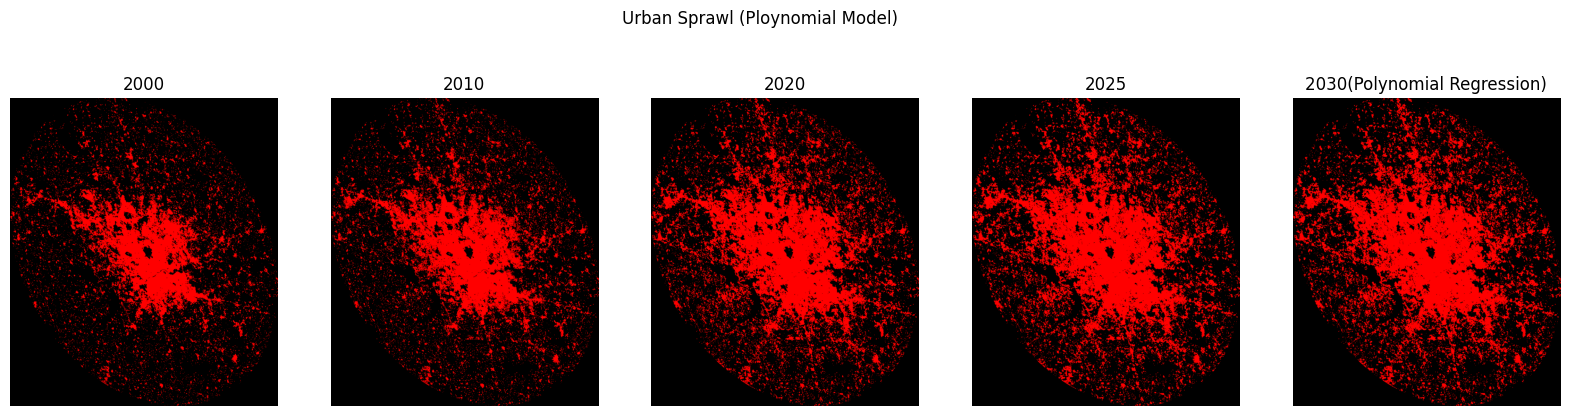

In [7]:
from matplotlib.colors import ListedColormap

fig, axes = plt.subplots(1, 5, figsize=(20,5))

imgs = [b2000, b2010, b2020, b2025, b2030]
titles = ['2000','2010','2020','2025','2030(Polynomial Regression)']

cmap = ListedColormap(['black', 'red'])

for i in range(5):
    axes[i].imshow(imgs[i], cmap=cmap)
    axes[i].set_title(titles[i])
    axes[i].axis('off')

plt.suptitle("Urban Sprawl (Ploynomial Model)")
plt.show()

Export code

In [21]:
import rasterio

with rasterio.open(r'C:\Users\aryaa\Desktop\URBAN SPRAWL MONITORING\Implementation\datasets\img\Built_2000_Hybd.tif') as src:
    profile = src.profile
    
profile.update(
    dtype=rasterio.uint8,   # since 0/1 classes
    count=1,
    compress='lzw'          # optional (smaller file)
)
with rasterio.open(r'C:\Users\aryaa\Desktop\URBAN SPRAWL MONITORING\Implementation\datasets\files\export_pred\Built_2030_Poly_Classified_Hydb.tif', 'w', **profile) as dst:
    dst.write(b2030.astype(rasterio.uint8), 1)

print("✅ Exported successfully!")



✅ Exported successfully!


Export updated

In [23]:
import rasterio

# Convert for visualization
b2030_p_visual = (b2030 * 255).astype(np.uint8)

with rasterio.open(r'C:\Users\aryaa\Desktop\URBAN SPRAWL MONITORING\Implementation\datasets\img\Built_2000_Hybd.tif') as src:
    profile = src.profile

profile.update(
    dtype=rasterio.uint8,
    count=1,
    compress='lzw'
)

with rasterio.open(r'C:\Users\aryaa\Desktop\URBAN SPRAWL MONITORING\Implementation\datasets\files\\Built_2030_Poly_Classified_Hybd_upd.tif', 'w', **profile) as dst:
    dst.write(b2030_p_visual, 1)

print("✅ Exported correctly!")

✅ Exported correctly!


NEW URBAN AREAS

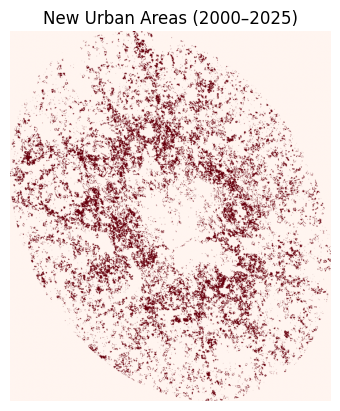

In [9]:
new_urban = (b2025 == 1) & (b2000 == 0)

plt.imshow(new_urban, cmap='Reds')
plt.title("New Urban Areas (2000–2025)")
plt.axis('off')
plt.show()

FUTURE EXPANSION

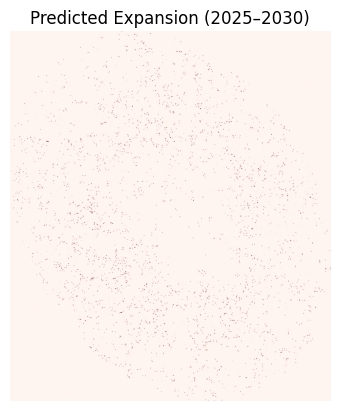

In [10]:
future_growth = (b2030 == 1) & (b2025 == 0)

plt.imshow(future_growth, cmap='Reds')
plt.title("Predicted Expansion (2025–2030)")
plt.axis('off')
plt.show()

AREA CALCULATION

In [11]:
pixel_area = (30*30)/1e6

def compute_area(mask):
    return np.sum(mask) * pixel_area

print("Future Expansion Area:", compute_area(future_growth), "km²")

Future Expansion Area: 30.1104 km²


RF IMPLEMENTATION

In [12]:
from sklearn.ensemble import RandomForestRegressor

# Prepare data
X = np.stack([img2000, img2010, img2020], axis=-1).reshape(-1, 3)
y = img2025.reshape(-1)

# Remove NaN
mask = ~np.isnan(X).any(axis=1) & ~np.isnan(y)
X = X[mask]
y = y[mask]

# Train model
rf = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42)
rf.fit(X, y)

# Predict
y_pred = rf.predict(X)

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("RF Validation:")
print("MAE:", mean_absolute_error(y, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y, y_pred)))
print("R²:", r2_score(y, y_pred))

RF Validation:
MAE: 0.07660612293483549
RMSE: 0.19140185568440485
R²: 0.8340299509791395


PREDICT 2030

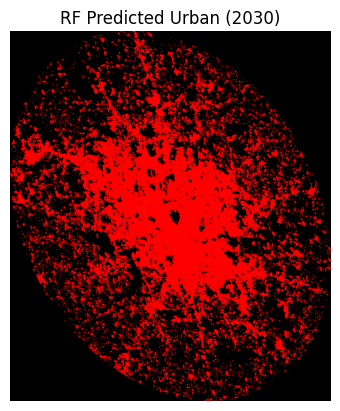

In [13]:
# Prepare 2030 input
X_full = np.stack([img2000, img2010, img2020, img2025], axis=-1)

# Use last 3 years
X_2030 = X_full[:, :, 1:].reshape(-1, 3)

mask_2030 = ~np.isnan(X_2030).any(axis=1)

pred_2030_rf = np.zeros(X_2030.shape[0])

pred_2030_rf[mask_2030] = rf.predict(X_2030[mask_2030])

img2030_rf = pred_2030_rf.reshape(img2000.shape)

img2030_rf = np.clip(img2030_rf, 0, 1)

b2030_rf = (img2030_rf > 0.2).astype(int)

cmap = ListedColormap(['black', 'red'])
plt.imshow(b2030_rf, cmap=cmap)
plt.title("RF Predicted Urban (2030)")
plt.axis('off')
plt.show()


In [22]:
import rasterio

with rasterio.open(r'C:\Users\aryaa\Desktop\URBAN SPRAWL MONITORING\Implementation\datasets\img\Built_2000_Hybd.tif') as src:
    profile = src.profile
    
profile.update(
    dtype=rasterio.uint8,   # since 0/1 classes
    count=1,
    compress='lzw'          # optional (smaller file)
)
with rasterio.open(r'C:\Users\aryaa\Desktop\URBAN SPRAWL MONITORING\Implementation\datasets\files\export_pred\Built_2030_RF_Classified_Hydb.tif', 'w', **profile) as dst:
    dst.write(b2030_rf.astype(rasterio.uint8), 1)

print("✅ Exported successfully!")



✅ Exported successfully!


export updated

In [24]:
import rasterio

# Convert for visualization
b2030_rf_visual = (b2030_rf * 255).astype(np.uint8)

with rasterio.open(r'C:\Users\aryaa\Desktop\URBAN SPRAWL MONITORING\Implementation\datasets\img\Built_2000_Hybd.tif') as src:
    profile = src.profile

profile.update(
    dtype=rasterio.uint8,
    count=1,
    compress='lzw'
)

with rasterio.open(r'C:\Users\aryaa\Desktop\URBAN SPRAWL MONITORING\Implementation\datasets\files\\Built_2030_RF_Classified_Hydb_upd.tif', 'w', **profile) as dst:
    dst.write(b2030_rf_visual, 1)

print("✅ Exported correctly!")

✅ Exported correctly!


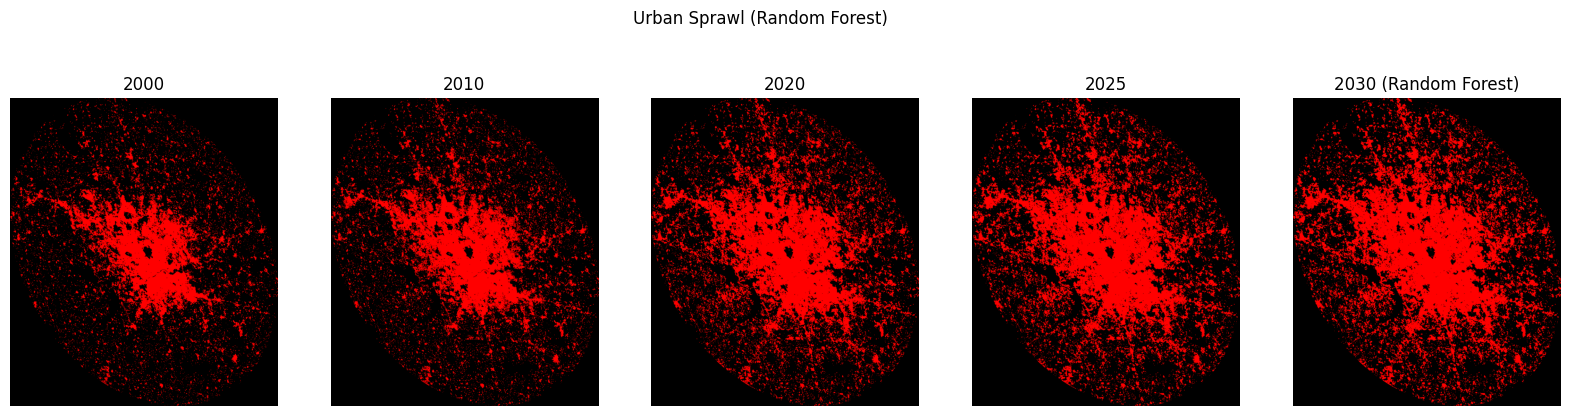

In [15]:
from matplotlib.colors import ListedColormap

fig, axes = plt.subplots(1, 5, figsize=(20,5))

imgs = [b2000, b2010, b2020, b2025, b2030_rf]
titles = ['2000','2010','2020','2025','2030 (Random Forest)']

cmap = ListedColormap(['black', 'red'])

for i in range(5):
    axes[i].imshow(imgs[i], cmap=cmap)
    axes[i].set_title(titles[i])
    axes[i].axis('off')

plt.suptitle("Urban Sprawl (Random Forest)")
plt.show()

AREA CALCULATION (POLY + RF)

In [16]:
pixel_area = (30 * 30) / 1e6  # km²

def compute_area(mask):
    return np.sum(mask) * pixel_area

In [17]:
future_poly = (b2030 == 1) & (b2025 == 0)

poly_area = compute_area(future_poly)

print("Polynomial Model Expansion (2025–2030):", poly_area, "km²")

future_rf = (b2030_rf == 1) & (b2025 == 0)

rf_area = compute_area(future_rf)

print("Random Forest Expansion (2025–2030):", rf_area, "km²")

Polynomial Model Expansion (2025–2030): 30.1104 km²
Random Forest Expansion (2025–2030): 127.8207 km²


In [18]:
print("\n===== MODEL COMPARISON =====")

print("\nPolynomial Model:")
print("Expansion Area:", poly_area, "km²")

print("\nRandom Forest Model:")
print("Expansion Area:", rf_area, "km²")


===== MODEL COMPARISON =====

Polynomial Model:
Expansion Area: 30.1104 km²

Random Forest Model:
Expansion Area: 127.8207 km²


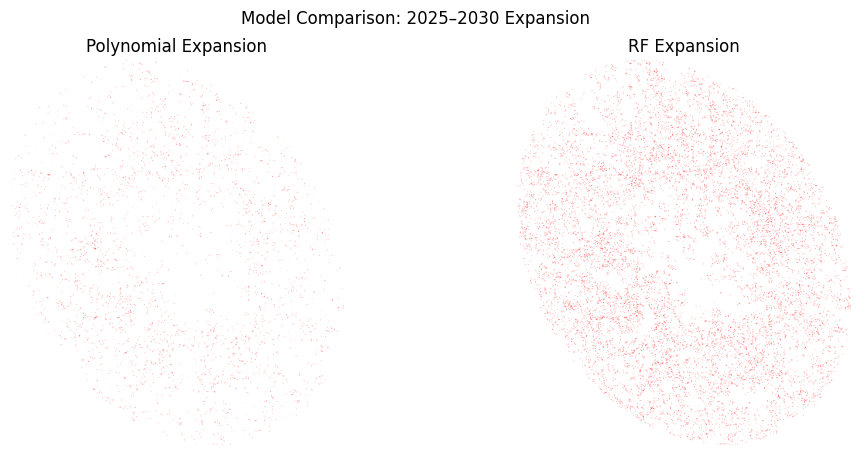

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

cmap = ListedColormap(['white', 'red'])

axes[0].imshow(future_poly, cmap=cmap)
axes[0].set_title("Polynomial Expansion")

axes[1].imshow(future_rf, cmap=cmap)
axes[1].set_title("RF Expansion")

for ax in axes:
    ax.axis('off')

plt.suptitle("Model Comparison: 2025–2030 Expansion")
plt.show()

(np.float64(-0.5), np.float64(2361.5), np.float64(2724.5), np.float64(-0.5))

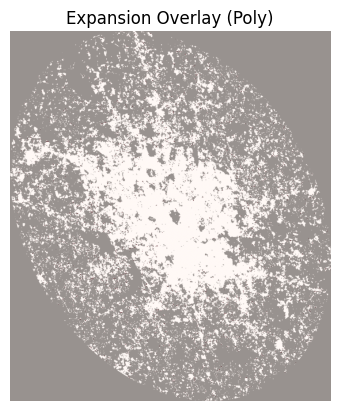

In [20]:
plt.imshow(b2025, cmap='gray')
plt.imshow(future_poly, cmap='Reds', alpha=0.6)
plt.title("Expansion Overlay (Poly)")
plt.axis('off')